In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import gc

## Use Geneformer embedded data

In [2]:
# Mouse brain geneformed-derived data
adata = sc.read_h5ad("ms2_geneformer.h5ad")
adata

AnnData object with n_obs × n_vars = 13468 × 512
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[developmental stage]', 'Sample Characteristic Ontology Term[developmental stage]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[sampling site]', 'Sample Characteristic Ontology Term[sampling site]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[organism status]', 'Sample Characteristic Ontology Term[organism status]', 'Sample Characteristic[cause of death]', 'Sample Characteristic Ontology Term[cause of death]', 'Sample Characteristic[clinical history]', 'Sample C

2025-04-30 16:59:56.970385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746046796.986244 3175845 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746046796.991356 3175845 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746046797.005041 3175845 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746046797.005055 3175845 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746046797.005057 3175845 computation_placer.cc:177] computation placer alr

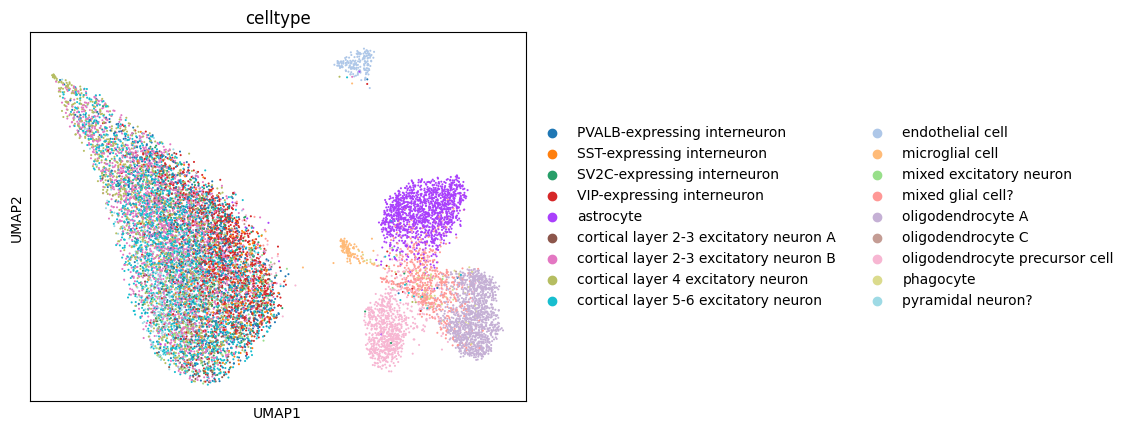

In [3]:
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=18, use_rep='X_pca')
sc.tl.umap(adata) 

# Cell type umap based oon scf generated embedding space
sc.pl.umap(adata, color="celltype", save= "Geneformer_generated_MS_embedding_umap.svg")

## Prepare data and split it to training, test, and validation subsets

In [4]:
db=adata.to_df()
y = adata.obs["celltype"]
x=db.iloc[:, 0:]

# split data
from sklearn.model_selection import train_test_split
X= db.iloc[:, 0:]
y= adata.obs["celltype"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size= 0.3, random_state= 42)

## Classes for classification

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [6]:
class TransformerClassifier(nn.Module):
    def __init__(self, embedding_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Linear(embedding_dim, hidden_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.embedding(x)  # Project input to hidden dimension
        x = x.unsqueeze(1)  # Ensure shape is (batch_size, seq_length=1, hidden_dim)
        x = self.transformer_encoder(x)  # Transformer encoder expects (seq_length, batch_size, hidden_dim)
        x = x.squeeze(1)  # Remove extra dimension
        logits = self.fc(x)  # Aggregate features along embedding space
        return self.softmax(logits)


# Training function
def train_classifier(X_train, y_train, X_validation, y_validation, X_test, y_test, embedding_dim, num_classes, epochs=10, lr=0.001, batch_size=32):
    model = TransformerClassifier(embedding_dim, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_validation, y_validation)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Validation step
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        
        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {loss.item():.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')
    
    return model


In [7]:
# Prediction function
def predict(model, X_test):
    with torch.no_grad():
        outputs = model(X_test)
        predicted_labels = torch.argmax(outputs, dim=1)
    return predicted_labels

In [8]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on all labels and transform them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_valid_encoded = label_encoder.transform(y_valid)
# Assuming your datasets are in NumPy arrays, convert them to PyTorch tensors
# Convert Pandas Series to NumPy arrays
X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)
X_valid_tensor = torch.tensor(np.array(X_valid), dtype=torch.float32)


In [9]:
# Convert labels to NumPy arrays with explicit integer conversion
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid_encoded, dtype=torch.long)

In [10]:
# Define parameters
embedding_dim = 512  # Based on input shape
#num_classes = len(torch.unique(y_train_tensor))  # Automatically infer number of classes
num_classes = 718# Because we have a total of 18 different cell types in our input data
epochs = 20  # Adjust based on training needs
lr = 0.001
batch_size = 32

In [11]:
# Train the model
model = train_classifier(
    X_train_tensor, y_train_tensor,
    X_valid_tensor, y_valid_tensor,
    X_test_tensor, y_test_tensor,
    embedding_dim, num_classes, 
    epochs=epochs, lr=lr, batch_size=batch_size
)

/home/mccwen/.local/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/20], Training Loss: 6.4210, Validation Loss: 6.4184
Epoch [2/20], Training Loss: 6.4736, Validation Loss: 6.4183
Epoch [3/20], Training Loss: 6.4736, Validation Loss: 6.4183
Epoch [4/20], Training Loss: 6.5262, Validation Loss: 6.4183
Epoch [5/20], Training Loss: 6.3683, Validation Loss: 6.4183
Epoch [6/20], Training Loss: 6.4736, Validation Loss: 6.4183
Epoch [7/20], Training Loss: 6.4210, Validation Loss: 6.4183
Epoch [8/20], Training Loss: 6.3157, Validation Loss: 6.4183
Epoch [9/20], Training Loss: 6.4210, Validation Loss: 6.4183
Epoch [10/20], Training Loss: 6.4736, Validation Loss: 6.4183
Epoch [11/20], Training Loss: 6.3683, Validation Loss: 6.4183
Epoch [12/20], Training Loss: 6.4210, Validation Loss: 6.4183
Epoch [13/20], Training Loss: 6.3157, Validation Loss: 6.4183
Epoch [14/20], Training Loss: 6.2631, Validation Loss: 6.4183
Epoch [15/20], Training Loss: 6.4210, Validation Loss: 6.4183
Epoch [16/20], Training Loss: 6.3683, Validation Loss: 6.4183
Epoch [17/20], Tr

### Predict cell types for the test data

In [17]:
predicted_labels = predict(model, X_test_tensor)
print("Predicted Labels:", predicted_labels)

Predicted Labels: tensor([6, 6, 6,  ..., 6, 6, 6])


In [23]:
#from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_curve, precision_score, recall_score

"""
# Calculate accuracy for each class
accuracy_per_class = []
for i in range(18):  # For each class
    class_mask = (y_test_tensor == i)
    class_accuracy = accuracy_score(y_test_tensor[class_mask], predicted_labels[class_mask])
    accuracy_per_class.append(class_accuracy)
"""

'\n# Calculate accuracy for each class\naccuracy_per_class = []\nfor i in range(18):  # For each class\n    class_mask = (y_test_tensor == i)\n    class_accuracy = accuracy_score(y_test_tensor[class_mask], predicted_labels[class_mask])\n    accuracy_per_class.append(class_accuracy)\n'

In [22]:
test_predicted_labels = predict(model, X_test_tensor)
accuracy =accuracy_score(y_test_tensor, test_predicted_labels)
print(f"Test Data Accuracy: {accuracy}")

# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_test_tensor, test_predicted_labels, average='macro')
print(f"Test Data F1 Score (Macro): {f1}")

precision_macro = precision_score(y_test_tensor, test_predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_test_tensor, test_predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_test_tensor, test_predicted_labels, average='macro', labels=range(18))
print(f"Test Data Precision: {precision_macro: .3f}")
print(f"Test Data Recall: {recall_macro: .3f}")
print(f"Test Data F1 Score: {f1_macro: .3f}")

Test Data Accuracy: 0.16831683168316833
Test Data F1 Score (Macro): 0.0160075329566855
Test Data Precision:  0.009
Test Data Recall:  0.056
Test Data F1 Score:  0.016


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Compare the true cell type labels with the predicted ones on validation data

In [21]:
# Compare the true cell types with the predicted ones on validation data
valid_predicted_labels = predict(model, X_valid_tensor)
accuracy =accuracy_score(y_valid_tensor, valid_predicted_labels)
print(f"Accuracy: {accuracy}")

# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_valid_tensor, valid_predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_valid_tensor, valid_predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
print(f"Validation precision: {precision_macro: .3f}")
print(f"Validation recall: {recall_macro: .3f}")
print(f"Validation F1 score: {f1_macro: .3f}")

Accuracy: 0.16075845012366036
F1 Score (Macro): 0.015388257575757576
F1 Score (Micro): 0.16075845012366036
Validation precision:  0.009
Validation recall:  0.056
Validation F1 score:  0.015


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
